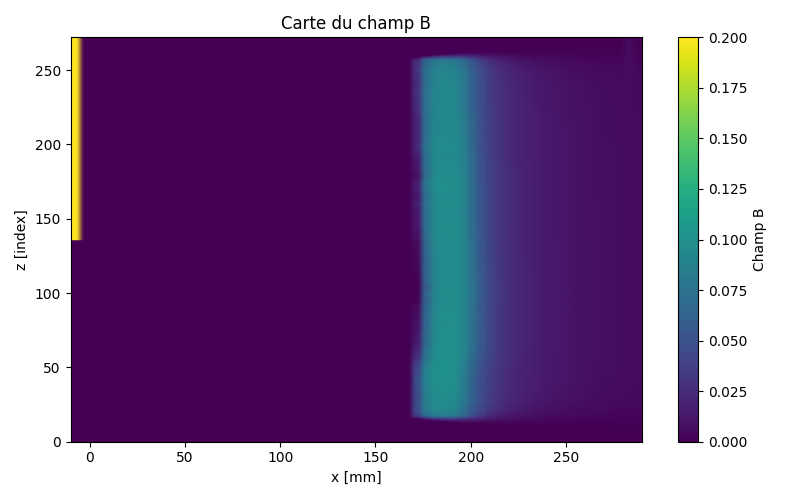

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import re

def extract_arrays_from_file(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    # Extraire tous les blocs entre crochets : [ ... ]
    matches = re.findall(r'\[[^\[\]]*\]', content)

    arrays = []
    for m in matches:
        try:
            arr = np.fromstring(m.strip('[]'), sep=' ')
            arrays.append(arr)
        except ValueError:
            print("Bloc ignoré :", m[:30], "...")
    return arrays

# Charger les données
arrays = extract_arrays_from_file('B_120_HallProbe_measured.txt')

# Vérification
if len(arrays) == 0:
    raise RuntimeError("Aucune donnée extraite du fichier.")

if len(set(len(a) for a in arrays)) > 1:
    raise ValueError("Les lignes ont des longueurs incohérentes.")

# Extraction des axes
x = arrays[0]
z_list = arrays[1:]
B_map = np.vstack(z_list)

# Axe z fictif
z = np.linspace(0, len(B_map)-1, len(B_map))

%matplotlib widget

# Affichage
plt.figure(figsize=(8, 5))
extent = [x.min(), x.max(), z.min(), z.max()]
plt.imshow(B_map, aspect='auto', origin='lower', extent=extent, cmap='viridis')
plt.colorbar(label='Champ B')
plt.xlabel('x [mm]')
plt.ylabel('z [index]')
plt.title('Carte du champ B')
plt.tight_layout()
plt.clim([0 , 0.2])
plt.show()
